# Load models and media and compare growth

In [13]:

import os
import sys
sys.path.insert(0, '/home/emma/Dokumente/thesis')

import pandas as pd
from cobra.io import read_sbml_model
import matplotlib.pyplot as plt
import seaborn as sns
import cobra
from collections import defaultdict
import numpy as np
from copy import deepcopy
from upsetplot import UpSet, from_indicators, from_contents
from venn import venn
import math
from functions import save_media, create_medium, get_exchanges, get_model_specific_medium

In [6]:
media_dir = "/home/emma/Dokumente/thesis/media_creation/created_media"
model_dir = "/home/emma/Dokumente/thesis/Model_generation_curation/Curated_models/mb1_mdr_rdr_dp_lib_bz"
media_save_dir = "/home/emma/Dokumente/thesis/media_creation/created_media"

In [7]:
met_class = "/home/emma/Dokumente/thesis/media_creation/category_metabolites.csv"

In [8]:
# Load and store all media 
AF7 = pd.read_csv(os.path.join(media_dir, "media_barley - 7dpi_AF_mock.csv"))
AF8 = pd.read_csv(os.path.join(media_dir, "media_barley - 8dpi_AF_mock.csv"))
Root7 = pd.read_csv(os.path.join(media_dir, "media_barley - 7dpi_Root_media_liquidphase.csv"))
Root8 = pd.read_csv(os.path.join(media_dir, "media_barley - 8dpi_Root_media_liquidphase.csv"))
TSB = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/TSB_medium.csv", header=None)

#### Functions

In [14]:
def assign_metaboliteclass_medium(medium, met_class_dict):
    medium_met_class = defaultdict(list)
    count_dict = defaultdict(int)
    for ex_r in medium.keys():
        if ex_r in met_class_dict.keys():
            mc = met_class_dict[ex_r]
            medium_met_class[mc].append(ex_r)
            count_dict[mc] += 1
        else:
            print(f"{ex_r} could not be found in metabolite lookup")
    return medium_met_class, count_dict

In [15]:
def save_media(medium_dict, medianame):
    medium_df = pd.DataFrame.from_dict(
        medium_dict, orient="index")
    filename = f"{medianame}.csv"
    filepath = os.path.join(media_save_dir, filename)
    medium_df.to_csv(filepath)    
    return medium_df

#### Create media from csv and compare growth on base media 

In [16]:
AF7 = create_medium(AF7)
AF8 = create_medium(AF8)
Root7 = create_medium(Root7)
Root8 = create_medium(Root8)
TSB = create_medium(TSB)

In [17]:
mediadict = {"AF7" : AF7, "AF8": AF8, "Root7": Root7, "Root8": Root8, "TSB": TSB}

In [18]:
compare_growth_media = {}

for file in os.listdir(model_dir):
    if not file.endswith(('.xml', '.sbml')):
        continue
        
    model = read_sbml_model(os.path.join(model_dir, file))
    model_id = model.id
    
    default_medium = model.medium.copy()
    
    cur_m = []
    
    sol_base = model.slim_optimize()
    cur_m.append(("Complete_Medium", sol_base))
    
    for med_name, cur_med in mediadict.items():
        try:
            medium_ = get_model_specific_medium(model, cur_med)
            model.medium = medium_
            
            sol = model.slim_optimize()
            cur_m.append((med_name, sol))
            
        except Exception as e:
            print(f"Error simulating {med_name} on model {model_id}: {e}")
            cur_m.append((med_name, 0.0)) 
            
        finally:
            model.medium = default_medium
            
    compare_growth_media[model_id] = cur_m

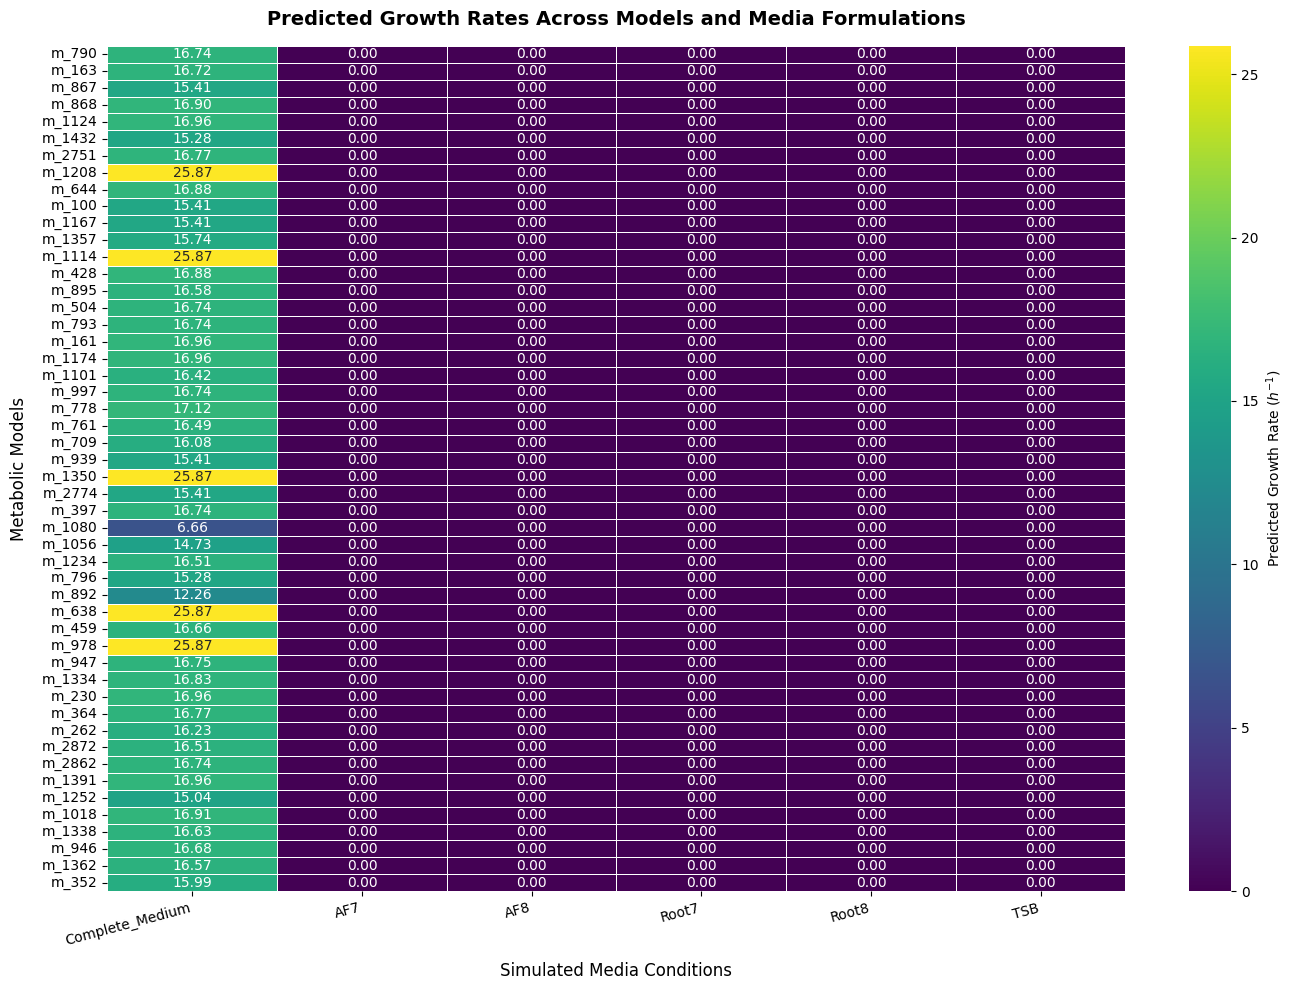

In [19]:
df_growthrate2medium = pd.DataFrame({
    model_id: dict(results) for model_id, results in compare_growth_media.items()
}).T

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df_growthrate2medium, 
    annot=True,              # Write the numeric growth rates inside the cells
    cmap='viridis',          # Clear color gradient (dark = no growth, yellow = fast growth)
    fmt=".2f",               # Format values to 2 decimal places
    linewidths=0.5,          # Subtle line grid separating cells
    cbar_kws={'label': 'Predicted Growth Rate ($h^{-1}$)'}, 
    ax=ax
)

ax.set_title('Predicted Growth Rates Across Models and Media Formulations', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Simulated Media Conditions', fontsize=12, labelpad=10)
ax.set_ylabel('Metabolic Models', fontsize=12, labelpad=10)

plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### Use COBRA minimal_medium to identify minimal medium: cobra.medium.minimal_medium.add_mip_obj

In [20]:
minimal_medium = {}
min_med_growth_rates = {}
for file in os.listdir(model_dir):
    if not file.endswith(('.xml')):
        continue
        
    model = read_sbml_model(os.path.join(model_dir, file))
    model_id = model.id
    #print(model_id)
    mini_med = cobra.medium.minimal_medium(model, 1.0, exports = True, minimize_components=True)
    minimal_medium[model_id] = mini_med

    if mini_med is not None:
        default_medium = model.medium.copy()
        try:
            model.medium = mini_med.to_dict() 
            growth_rate = model.slim_optimize()
            min_med_growth_rates[model_id] = growth_rate if not np.isnan(growth_rate) else 0.0
        except Exception as e:
            print(f"Error calculating growth on minimal medium for {model_id}: {e}")
            min_med_growth_rates[model_id] = 0.0
        finally:
            model.medium = default_medium  
    else:
        # If no minimal medium was found, growth rate is 0.0
        min_med_growth_rates[model_id] = 0.0

In [21]:
# list of all EX_reactions from minimal_media
count_mods_per_reaction = defaultdict(list)

for model_id, medium in minimal_medium.items():
    if medium is None:
        print(f"Skipping {model_id} because no minimal medium could be found.")
        continue
    for ex_r, flux in medium.items():
        if flux > 0:
            count_mods_per_reaction[ex_r].append(model_id)

In [22]:
# figure out which ex_r are missing in the predefined media
ex_r_missinginmedia = defaultdict(list)
for ex_r, counts in count_mods_per_reaction.items():
    if len(counts) >=1:
        for media_id, medium in mediadict.items():
            if ex_r not in medium.keys():
                ex_r_missinginmedia[ex_r].append(media_id)

In [23]:
# Find all reactions missing from the all media
reactions_missing_in_all_media = [
    ex_r for ex_r, media_list in ex_r_missinginmedia.items() if len(media_list) == 5
]

print(f"Reactions missing in all media and at least 5 models: {reactions_missing_in_all_media}")
print(f"Count: {len(reactions_missing_in_all_media)}")

Reactions missing in all media and at least 5 models: ['EX_3ump_e', 'EX_6pgc_e', 'EX_LalaDgluMdap_e', 'EX_R_3httdca_e', 'EX_acgam1p_e', 'EX_acnam_e', 'EX_ala_leu_e', 'EX_alaala_e', 'EX_amp_e', 'EX_bz_e', 'EX_cmp_e', 'EX_coa_e', 'EX_dtmp_e', 'EX_glyc3p_e', 'EX_gmp_e', 'EX_h2s_e', 'EX_nmn_e', 'EX_pheme_e', 'EX_pydxn_e', 'EX_sheme_e', 'EX_uaccg_e', 'EX_lysglugly_e', 'EX_pydam_e', 'EX_uri_e', 'EX_for_e', 'EX_g6p_e', 'EX_icit_e', 'EX_5mcsn_e', 'EX_acmana_e', 'EX_dhap_e', 'EX_g3pg_e', 'EX_gly_leu_e', 'EX_meoh_e', 'EX_orn_e', 'EX_pep_e', 'EX_prohisglu_e', 'EX_s_e', 'EX_mevR_e', 'EX_pydx_e', 'EX_5oxpro_e', 'EX_cytd_e', 'EX_glyglygln_e', 'EX_LalaDgluMdapDala_e', 'EX_acald_e', 'EX_alagly_e', 'EX_asp__D_e', 'EX_fe3pyovd_kt_e', 'EX_hcys__L_e', 'EX_mmet_e', 'EX_nac_e', 'EX_no3_e', 'EX_sbt__D_e', 'EX_udcpp_e', 'EX_ump_e', 'EX_3amp_e', 'EX_argp_e', 'EX_ch4s_e', 'EX_gsn_e', 'EX_tton_e', 'EX_galctn__D_e', 'EX_peng_e', 'EX_adn_e', 'EX_f6p_e', 'EX_indole_e', 'EX_so4_e', 'EX_ala_L_asp__L_e', 'EX_fald_e', 

In [24]:
missing_TSB = [reac_id for reac_id, media_ids in ex_r_missinginmedia.items() if "TSB" in media_ids]

#### complete media with minimal media results 

In [25]:
# add all missing reactions to the predef media and see how they grow
completed_media = {}
for medium_id, reactions in mediadict.items():
    medium_id_new = f"{medium_id}_completed"
    completed_media[medium_id_new] = deepcopy(reactions)

for ex_r in missing_TSB:
    #for medium_id in medium_ids:
    medium_id_new = medium_id + "_completed"
    completed_media[medium_id_new][ex_r] = 10.0


TSB_completed_micom = completed TSB medium for the communites and then these combined, see create_communities_andgetminimalmedia

In [40]:
TSB_completed_micom_e = pd.read_csv("/home/emma/Dokumente/thesis/media_creation/created_media/Completed_TSB.csv")

In [41]:
TSB_completed_micom_e = create_medium(TSB_completed_micom_e)

In [44]:
# need to rename _m to _e
TSB_completed_micom = {
    key.replace("_m", "_e"): value for key, value in TSB_completed_micom_e.items()
}


In [45]:
# media of interest 
target_media = { }
target_media["TSB_community_complete"] = TSB_completed_micom
target_media["TSB_minimed"] = completed_media["TSB_completed"]

In [49]:
compare_growth_media_complete = {}

for file in os.listdir(model_dir):
    if not file.endswith(('.xml', '.sbml')):
        continue
        
    model = read_sbml_model(os.path.join(model_dir, file))
    model_id = model.id
    
    default_medium = model.medium.copy()
    
    cur_m = []
    
    sol_base = model.slim_optimize()
    cur_m.append(("Complete_Medium", sol_base))
    
    for med_name, cur_med in target_media.items():
        try:
            medium_ = get_model_specific_medium(model, cur_med)
            
            # --- FIX 1: Sanitize the incoming medium dictionary ---
            # Remove any keys that have nan values before applying to the model
            clean_medium = {
                rxn_id: val for rxn_id, val in medium_.items() 
                if not (isinstance(val, float) and math.isnan(val))
            }
            
            model.medium = clean_medium
            print(model.medium)
            sol = model.slim_optimize()
            if math.isnan(sol):
                sol = 0.0
                
            cur_m.append((med_name, sol))
            
        except Exception as e:
            print(f"Error simulating {med_name} on model {model_id}: {e}")
            cur_m.append((med_name, 0.0)) 
            
        finally:
            # --- FIX 2: Safeguard the reset ---
            # Reset to default medium
            model.medium = default_medium
            
    compare_growth_media_complete[model_id] = cur_m

{'EX_3ump_e': 0.001789457234357, 'EX_6pgc_e': 0.0033225782631612, 'EX_LalaDgluMdap_e': 0.0073641944286015, 'EX_R_3httdca_e': 0.0064722399115009, 'EX_acgam1p_e': 0.0038655958373575, 'EX_acnam_e': 0.0025138688763015, 'EX_ala_leu_e': 0.0217159999731498, 'EX_alaala_e': 0.0075340962310001, 'EX_amp_e': 0.022420155557392, 'EX_arg__L_e': 100.0, 'EX_bz_e': 1.5774514294964897e-05, 'EX_ca2_e': 10.0, 'EX_cl_e': 10.0, 'EX_cmp_e': 0.0180652679326324, 'EX_coa_e': 9.307656258577906e-05, 'EX_cobalt2_e': 10.0, 'EX_cu2_e': 10.0, 'EX_dtmp_e': 0.0042281967649666, 'EX_fe2_e': 10.0, 'EX_fol_e': 10.0, 'EX_gln__L_e': 100.0, 'EX_gly_asn__L_e': 100.0, 'EX_glyc3p_e': 0.0106857339243066, 'EX_gmp_e': 0.0240268835111571, 'EX_h2_e': 1000.0, 'EX_h2o_e': 1000.0, 'EX_h_e': 1000.0, 'EX_hdca_e': 10.0, 'EX_his__L_e': 100.0, 'EX_icit_e': 0.0005259164367564, 'EX_ile__L_e': 100.0, 'EX_k_e': 10.0, 'EX_lys__L_e': 100.0, 'EX_nmn_e': 0.0003067747832232, 'EX_o2_e': 1000.0, 'EX_phe__L_e': 100.0, 'EX_pheme_e': 2.064792100200005e-05,

In [47]:
df_growthrate2medium_complete = pd.DataFrame({
    model_id: dict(results) for model_id, results in compare_growth_media_complete.items()
}).T

df_filtered = df_growthrate2medium_complete[(df_growthrate2medium_complete > 0).any(axis=1)]

dropped_count = len(df_growthrate2medium) - len(df_filtered)
if dropped_count > 0:
    print(f"Removed {dropped_count} model(s) with zero growth across all conditions.")

In [ ]:
df_growthrate_TSB = pd.concat([
    df_growthrate2medium["Complete_Medium"].rename("Complete Medium"),
    df_growthrate2medium["TSB"].rename("TSB"), 
    df_growthrate2medium_complete["TSB_completed"].rename("TSB Complete"), 
    
], axis=1)

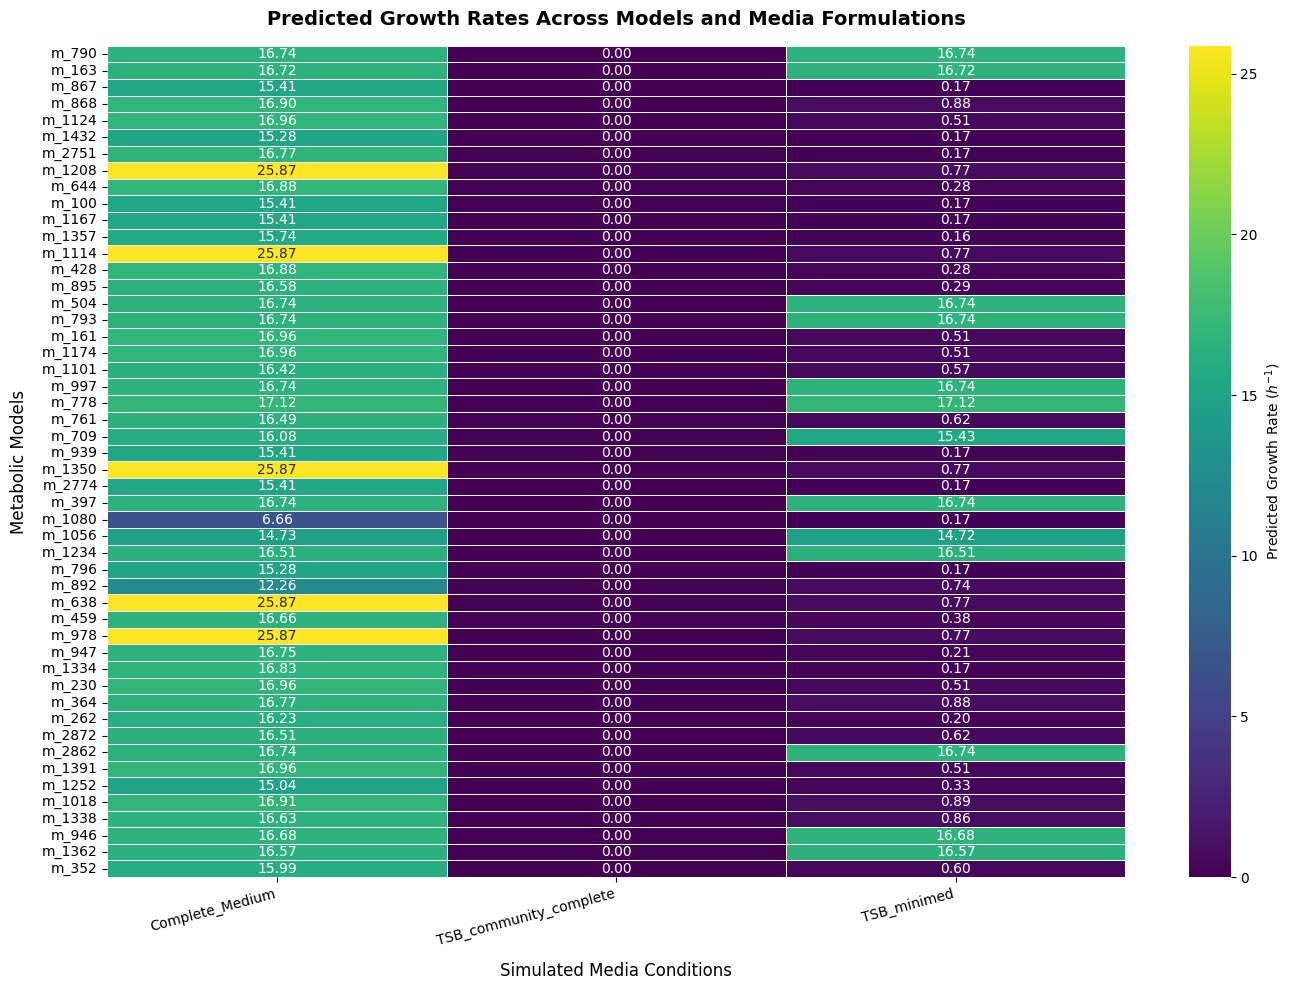

In [48]:
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    df_filtered,
    #df_filtered.iloc[:,[0, 5]],
    annot=True,              # Write the numeric growth rates inside the cells
    cmap='viridis',          # Clear color gradient (dark = no growth, yellow = fast growth)
    fmt=".2f",               # Format values to 2 decimal places
    linewidths=0.5,          # Subtle line grid separating cells
    cbar_kws={'label': 'Predicted Growth Rate ($h^{-1}$)'}, 
    ax=ax
)

ax.set_title('Predicted Growth Rates Across Models and Media Formulations', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Simulated Media Conditions', fontsize=12, labelpad=10)
ax.set_ylabel('Metabolic Models', fontsize=12, labelpad=10)

plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [36]:
# sve TSB complete medium 
save_media(completed_media["TSB_completed"], "TSB_completed")

,0
EX_glc__D_e,10.0
EX_na1_e,10.0
EX_cl_e,10.0
EX_k_e,10.0
EX_pi_e,10.0
...,...
EX_ddca_e,10.0
EX_ttdcea_e,10.0
EX_pser__L_e,10.0
EX_tyr__D_e,10.0


### compare the different media on their own 

In [19]:
all_media_comps = defaultdict(list)

for media_id, medium in mediadict.items():
    for ex_r in medium.keys():
        all_media_comps[ex_r].append(media_id)

#### what do they share?

In [ ]:
medium = {"AF7": set(AF7.keys()), "AF8": set(AF8.keys()), "Root7" : set(Root7.keys()), "Root8" : set(Root8.keys())}
venn(medium)

Text(0.5, 0, 'Amount medium components')

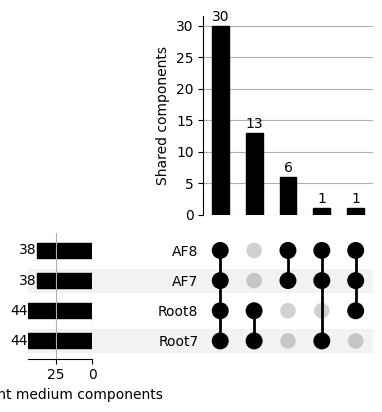

In [77]:
data = from_contents(medium)
upset = UpSet(data, show_counts=True, sort_by='cardinality')
axes = upset.plot()

# Y-axis of main plot
axes['intersections'].set_ylabel("Shared components")

# X-axis of totals
axes['totals'].set_xlabel("Amount medium components")


#### compare metabolite classes in media

In [36]:
met_class_df = pd.read_csv(met_class)
met_class_dict = dict(zip(met_class_df["Reaction"], met_class_df["Category"]))

In [37]:
as_d, count_d = assign_metaboliteclass_medium(AF7, met_class_dict)

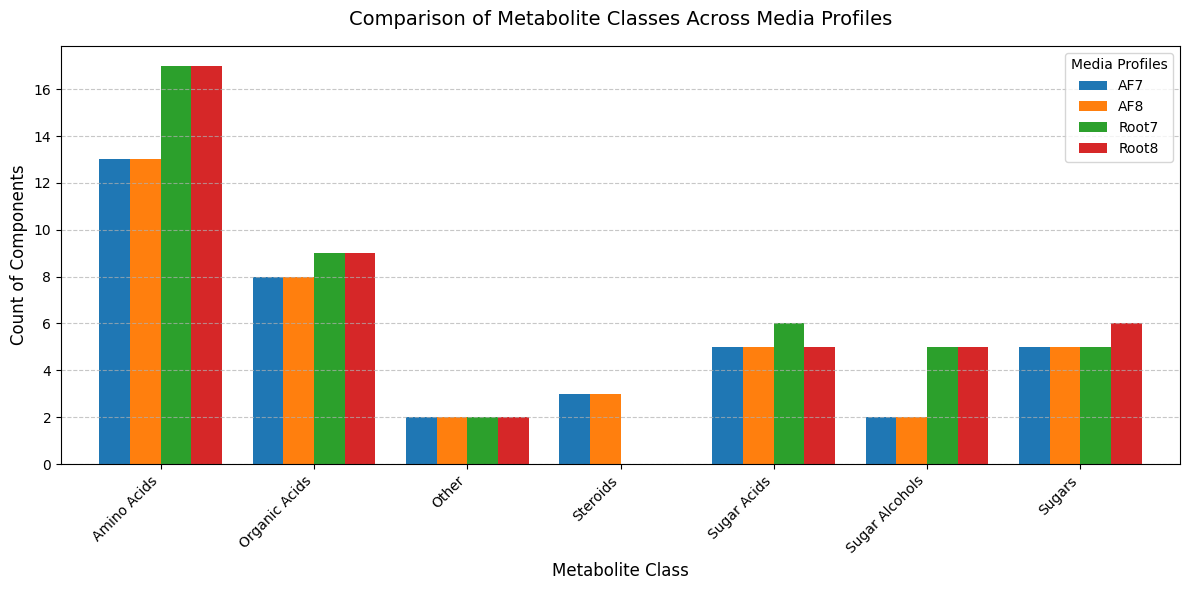

In [46]:
all_media_counts = {}

for med_id, medium in mediadict.items():
    as_d, c_d = assign_metaboliteclass_medium(medium, met_class_dict)
    all_media_counts[med_id] = c_d


df_counts = pd.DataFrame(all_media_counts).fillna(0)
df_counts = df_counts.sort_index()
ax = df_counts.plot(kind='bar', figsize=(12, 6), width=0.8)

plt.title("Comparison of Metabolite Classes Across Media Profiles", fontsize=14, pad=15)
plt.xlabel("Metabolite Class", fontsize=12)
plt.ylabel("Count of Components", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Media Profiles")

plt.tight_layout()
plt.show()